
# XGBoost Classifier — Breast Cancer Classification (Benign or Malignant)

In [1]:
# Load pacakges
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("XGBoost version:", xgb.__version__)


XGBoost version: 3.4.1


# **1. Load the Dataset**


#### The Breast Cancer Wisconsin dataset - built-in breast cancer dataset from scikit-learn

In [4]:
# Load Breast Cancer Wisconsin dataset
data = load_breast_cancer()

# **Convert the raw data into X (features) and y (target)**

X = input variables/features used by the model to make predictions

y = the outcome/class that we want the model to predict


In [5]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

In [10]:
# Dataset dimensions
print("Number of rows:", data.data.shape[0])
print("Number of columns:", data.data.shape[1])
print("Dimensions:", data.data.shape)


First 5 rows and first 5 columns:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
0,17.99,10.38,122.80,1001.0,0.11840
1,20.57,17.77,132.90,1326.0,0.08474
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
4,20.29,14.34,135.10,1297.0,0.10030


Number of rows: 569
Number of columns: 30
Dimensions: (569, 30)


In [21]:
# Column names
print("\nColumn names:")
print(data.feature_names)

# Row names / sample IDs
print("\nRow names:")
print(data.data.shape[0], "samples")

# Check whether sample/row names are provided
print("\nRow names available:", hasattr(data, "index"))


Column names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Row names:
569 samples

Row names available: False


In [25]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nClass distribution:")
print(y.value_counts().sort_index())

print("\nMissing values:", X.isna().sum().sum())


Number of samples: 569
Number of features: 30

Class distribution:
target
0    212
1    357
Name: count, dtype: int64

Missing values: 0


The Breast Cancer Wisconsin dataset contains numerical features and does not contain missing values, so no unnecessary preprocessing or scaling is introduced.


# **2. Understand the Target Labels**

Always check how the target is encoded before interpreting the confusion matrix.

For this dataset:

- `0` = **malignant**
- `1` = **benign**


In [12]:

target_summary = pd.DataFrame({
    "class_id": [0, 1],
    "class_name": data.target_names,
    "count": [int((y == 0).sum()), int((y == 1).sum())]
})

display(target_summary)


,class_id,class_name,count
0,0,malignant,212
1,1,benign,357


# **3. Split the data**

In [13]:
# keep 20% completely untouched for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y           # same class proportions in the training and test sets as in the complete dataset.
)

print("Training samples:", X_train.shape[0])
print("Test samples:    ", X_test.shape[0])

Training samples: 455
Test samples:     114



The test set will **not** be used for:
- hyperparameter tuning,
- cross-validation,
- early stopping,
- selecting the final model.

This prevents test-set leakage.


# **4. Split Training Data into Training and Validation Sets**

In [5]:

# Validation set is used for early stopping.
# It is created only from the training data.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Model-training samples:", X_tr.shape[0])
print("Validation samples:    ", X_val.shape[0])
print("Final test samples:    ", X_test.shape[0])


Model-training samples: 364
Validation samples:     91
Final test samples:     114


# **5. Train a Baseline XGBoost Classifier**

In [14]:
baseline_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,  #maximum number of boosting rounds/trees - no. of trees
    max_depth=3,  # simpler or complex trees - n = 3 means shallow
    learning_rate=0.05,  # mcontrols how strongly each new tree contributes to the overall model
    random_state=42,
    tree_method="hist" #use the histogram-based tree construction method.
)



baseline_model.fit(X_train, y_train) # actual learning

# make class prediction
baseline_pred = baseline_model.predict(X_test)

# Get predicted probabilities
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

print(f"Baseline accuracy: {accuracy_score(y_test, baseline_pred):.3f}")
print(f"Baseline ROC-AUC:  {roc_auc_score(y_test, baseline_prob):.3f}")


Baseline accuracy: 0.947
Baseline ROC-AUC:  0.993



The baseline gives us a reference point. We now tune the model using **cross-validation on the training data only**.


# **6. Hyperparameter Tuning with Cross-Validation**

The goal is to find the XGBoost settings that give the best performance using 5-fold stratified cross-validation.

In [7]:
# Candidate hyperparameters
param_grid = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05, 0.10],
    "n_estimators": [100, 200, 400],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Stratified CV preserves class proportions in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tuning_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist"
)

grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:")
print(grid_search.best_params_)

print(f"\nBest mean CV ROC-AUC: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 400, 'subsample': 0.8}

Best mean CV ROC-AUC: 0.9954



### Why use ROC-AUC for tuning?

For binary classification, ROC-AUC evaluates how well the model separates the two classes across probability thresholds rather than depending on a single 0.5 threshold.

The scoring metric can be changed according to the scientific or clinical objective. For example, `recall` may be more appropriate when missing a positive case is particularly costly.


# **7. Inspect the Cross-Validation Results**

In [8]:

cv_results = pd.DataFrame(grid_search.cv_results_)

results_table = (
    cv_results[
        [
            "param_max_depth",
            "param_learning_rate",
            "param_n_estimators",
            "param_subsample",
            "param_colsample_bytree",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

display(results_table)


,param_max_depth,param_learning_rate,param_n_estimators,param_subsample,param_colsample_bytree,mean_test_score,std_test_score
40,2,0.10,400,0.8,0.8,0.995356,0.003707
38,2,0.10,200,0.8,0.8,0.995253,0.003596
76,2,0.05,400,0.8,1.0,0.995150,0.004084
4,2,0.03,400,0.8,0.8,0.994943,0.003797
52,4,0.10,400,0.8,0.8,0.994634,0.003584
22,2,0.05,400,0.8,0.8,0.994530,0.004005
50,4,0.10,200,0.8,0.8,0.994324,0.003721
100,3,0.10,400,0.8,1.0,0.994324,0.003848
46,3,0.10,400,0.8,0.8,0.994324,0.004463
58,2,0.03,400,0.8,1.0,0.994324,0.004785


# **8. Final XGBoost Model with Early Stopping**


Now we take the best hyperparameters identified using cross-validation and train the final development model.

We deliberately give the model a large `n_estimators` value and use **early stopping** to determine how many boosting rounds are actually useful.

The validation set is used only for early stopping. The test set is still untouched.


In [9]:

best_params = grid_search.best_params_.copy()

# Do not keep the GridSearchCV n_estimators as the final stopping point.
# Give XGBoost many possible boosting rounds and let early stopping choose.
best_params["n_estimators"] = 2000

final_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    early_stopping_rounds=50,
    **best_params
)

final_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("Best boosting iteration:", final_model.best_iteration)
print("Best validation logloss:", final_model.best_score)


Best boosting iteration: 82
Best validation logloss: 0.13479305627745586


## 9. Check for Overfitting with the Learning Curve

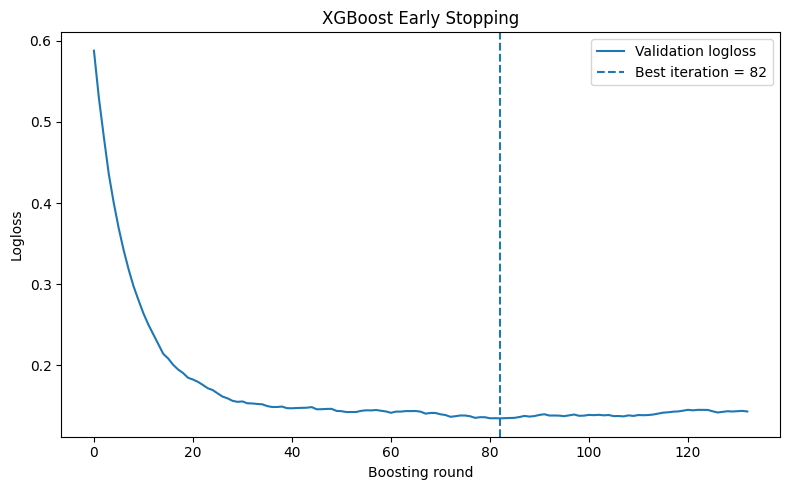

In [10]:

evals_result = final_model.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(
    evals_result["validation_0"]["logloss"],
    label="Validation logloss"
)

plt.axvline(
    final_model.best_iteration,
    linestyle="--",
    label=f"Best iteration = {final_model.best_iteration}"
)

plt.xlabel("Boosting round")
plt.ylabel("Logloss")
plt.title("XGBoost Early Stopping")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Final Evaluation on the Held-Out Test Set

In [11]:

# The test set is used here for the first time after model development.
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("FINAL TEST-SET PERFORMANCE")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


FINAL TEST-SET PERFORMANCE
-----------------------------------
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-score : 0.9655
ROC-AUC  : 0.9917


In [12]:

print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))


              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 11. Confusion Matrix

Confusion matrix:
[[39  3]
 [ 2 70]]


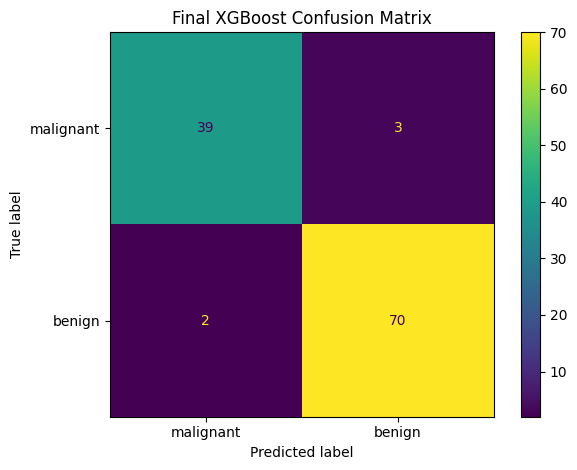

In [13]:

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("Confusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(values_format="d")
plt.title("Final XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()



### Medical interpretation

Because `0 = malignant` and `1 = benign` in this dataset, inspect the matrix carefully before describing errors.

In particular, a **malignant tumor predicted as benign** is a false negative with respect to the malignant class. The clinical importance of false negatives versus false positives should be considered when selecting the operating threshold.


## 12. ROC Curve

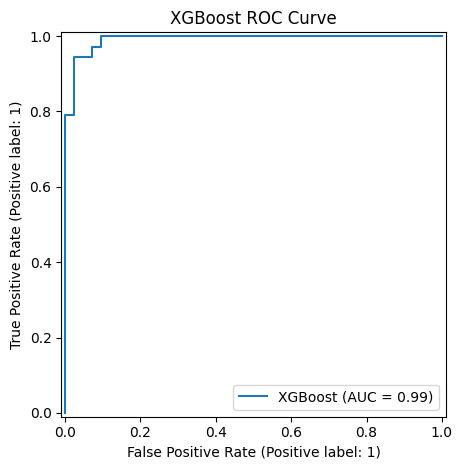

In [14]:

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="XGBoost"
)

plt.title("XGBoost ROC Curve")
plt.tight_layout()
plt.show()


## 13. Feature Importance

In [15]:

# XGBoost's built-in feature importance
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

display(importance.head(15))


,feature,importance
22,worst perimeter,0.309440
27,worst concave points,0.156681
25,worst compactness,0.148502
20,worst radius,0.071175
23,worst area,0.056650
1,mean texture,0.033189
13,area error,0.027467
7,mean concave points,0.026237
19,fractal dimension error,0.023468
6,mean concavity,0.021294


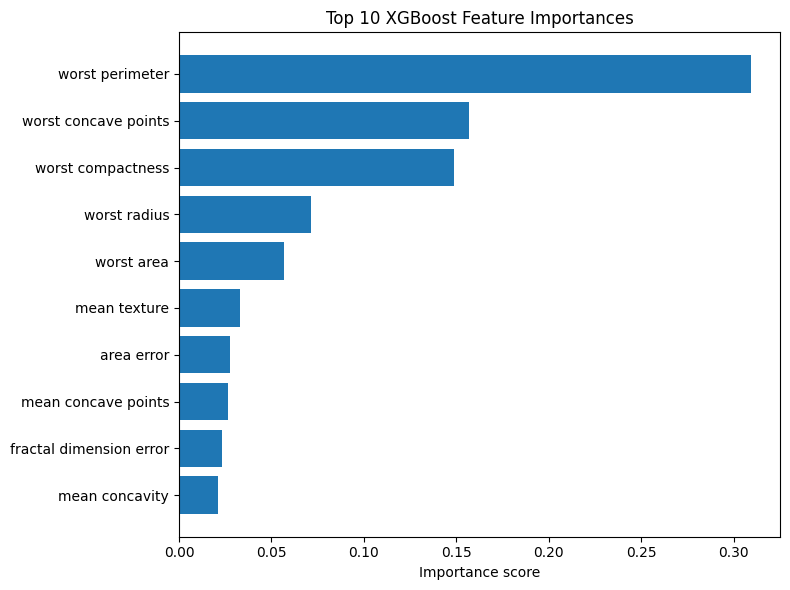

In [16]:

top_features = importance.head(10).sort_values("importance")

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance score")
plt.title("Top 10 XGBoost Feature Importances")
plt.tight_layout()
plt.show()



> **Important:** Feature importance indicates which variables were useful to the fitted model. It does not prove that those variables are biologically causal, nor does it by itself provide a complete explanation of individual predictions. SHAP is a useful next step for model interpretation.


## 14. Compare Baseline vs Final Model

In [17]:

comparison = pd.DataFrame({
    "Model": ["Baseline XGBoost", "Tuned + Early-Stopped XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, y_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, y_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, y_pred)
    ],
    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, y_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, y_prob)
    ]
})

display(comparison.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline XGBoost,0.9474,0.9459,0.9722,0.9589,0.9927
1,Tuned + Early-Stopped XGBoost,0.9561,0.9589,0.9722,0.9655,0.9917
